In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
from numba import cuda
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples

plt.style.use("../science.mplstyle")

In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:


BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5



ZUKO_ID = "UNAF"
NAME = "M_2048"
BATCH_SIZE = 512
NUM_COND_INPUTS = 0
COLLECTION_NAME = "OuterTrackerBarrelCollection"
SEED = 8



working_dir = "/pscratch/sd/r/rmastand/muon_collider"


In [4]:
save_dir = f"{working_dir}/zuko_outputs/{ZUKO_ID}/{NAME}"


with open(f"{save_dir}/wandb/latest-run/files/config.yaml") as ifile:
    configs = yaml.safe_load(ifile)

In [5]:

# computingtorch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [6]:

feature_labels = ["log($E$) [Gev]", "$x$", "$y$", "$z$", "$t$ [s]", "context"]
log_vars = []

In [7]:

data = []
context = []


tmp_data = np.load(f"{working_dir}/npys/nuGun_pT_0_50/{COLLECTION_NAME}_SimTrackerHit.npy")
data.append(tmp_data[:int(len(tmp_data)*.1)])


data = np.vstack(data)[:,[0,2,3,4,5]]
#data = data[data[:,0] > 2e-6]
data[:,0] = np.log(data[:,0])

bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 3), np.max(data[:,i] + 3), NUM_BINS) 

In [8]:


X_preproc = preprocess_data(data, ".", ZUKO_ID)
if NUM_COND_INPUTS == 1:
    X_preproc = np.hstack([X_preproc,  context])
elif NUM_COND_INPUTS == 0:
    pass
else:
    print("ERROR")
    exit()



In [9]:


hidden_features = [int(x) for x in configs["HIDDEN_FEATURES"]["value"].split(",")]


if ZUKO_ID == "NSF":
    flow = zuko.flows.NSF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features).to(device)
elif ZUKO_ID == "NCSF":
    flow = zuko.flows.NCSF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features, bins=16).to(device)
elif ZUKO_ID == "SOSPF":
    flow = zuko.flows.SOSPF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features, degree=4, polynomials=3).to(device)
elif ZUKO_ID == "UNAF":
    flow = zuko.flows.UNAF(5, 0, transforms=configs["TRANSFORMS"]["value"], hidden_features=hidden_features).to(device)
elif ZUKO_ID == "CNF":
    flow = zuko.flows.CNF(5, 0, hidden_features=hidden_features, freqs=configs["FREQS"]["value"]).to(device)
else:
    print("ERROR: Unknown ZUKO_ID")
    exit()


num_params = count_parameters(flow)
print(f"Number of trainable parameters: {num_params}")



Number of trainable parameters: 358210


In [10]:


print("Making flow samples...")

eval_flow = flow

eval_flow.load_state_dict(torch.load(f"{save_dir}/test.pt"))

num_samples_total = data.shape[0] 
sample_batch_size = 8192

samples_flow = []
for i in tqdm(range(0, num_samples_total, sample_batch_size)):
    if i + sample_batch_size > num_samples_total:
        nn = num_samples_total - i
    else:
        nn = sample_batch_size
    loc_samples = eval_flow().sample((nn,)).detach().cpu().numpy()
    samples_flow.append(loc_samples)
samples_flow = np.concatenate(samples_flow)

X_samples = {
        "flow_samples":samples_flow
        }



Making flow samples...


100%|██████████| 83/83 [04:36<00:00,  3.33s/it]


In [11]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , ".", ZUKO_ID)

auc 0.6404420654423111 \pm 0.000709245538147706. best epoch 299 of 300.



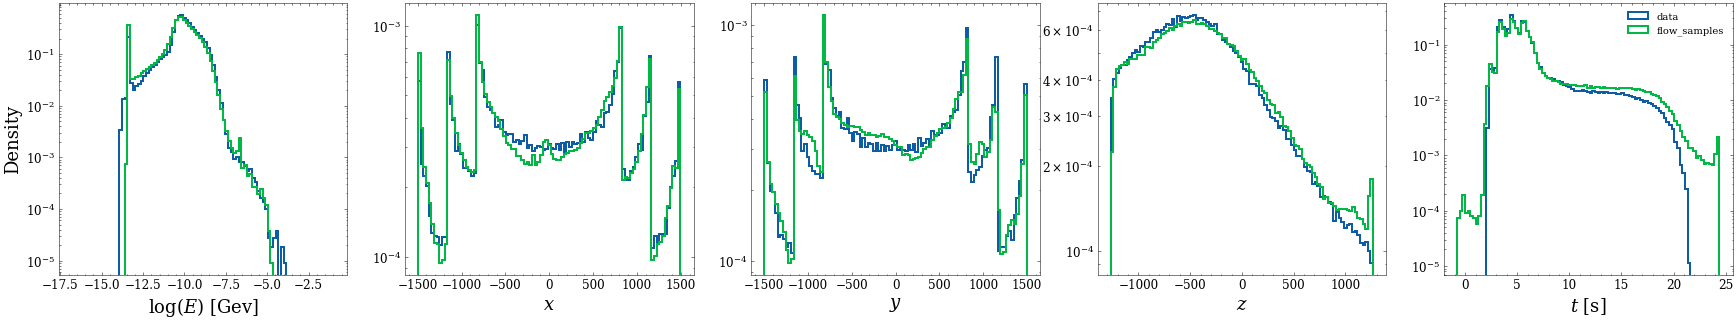

In [12]:

plot_hists_1d({"data":data, **X_samples}, bins_dict, log_dims=log_vars, labels=feature_labels)


try:
    with open(f"{save_dir}/results.txt") as ifile:
        a = ifile.readlines()[-1]
        print(a)
except:
    pass

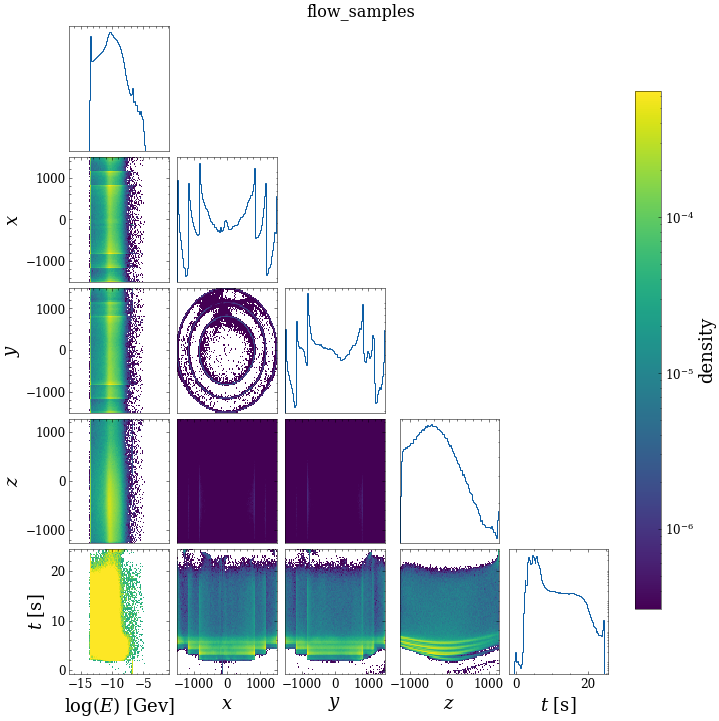

In [13]:
for key in X_samples.keys():
    fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )



# Restrict layers

Num. hits before mask: 678750
Num. hits after mask: 678750


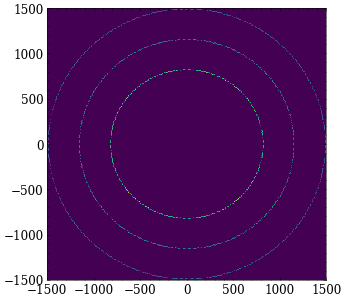

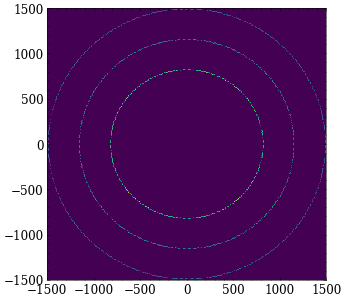

In [14]:

# https://github.com/key4hep/k4geo/blob/main/MuColl/MAIA/compact/MAIA_v0/OuterTracker_o2_v06_01.xml


def get_x_y_mask(X, layer_radii=(819, 1153, 1486), thickness=15):
    layer_radii = np.asarray(layer_radii)   # convert list → numpy array
    half_t = thickness / 2

    r = np.sqrt(X[:,1]**2 + X[:,2]**2)

    mask = np.any(
        np.abs(r[:, None] - layer_radii[None, :]) <= half_t,
        axis=1
    )
    return mask


m = get_x_y_mask(data)
print("Num. hits before mask:", len(m))
print("Num. hits after mask:", sum(m))


plt.figure(figsize = (5,5))
plt.hist2d(data[:,1], data[:,2], bins = [np.linspace(-1500,1500,500), np.linspace(-1500,1500,500)])
plt.show()


plt.figure(figsize = (5,5))
plt.hist2d(data[m][:,1], data[m][:,2], bins = [np.linspace(-1500,1500,500), np.linspace(-1500,1500,500)])
plt.show()

Num. hits before mask: 678750
Num. hits after mask: 495217


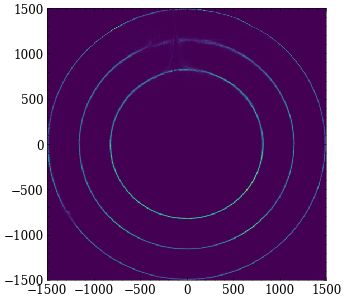

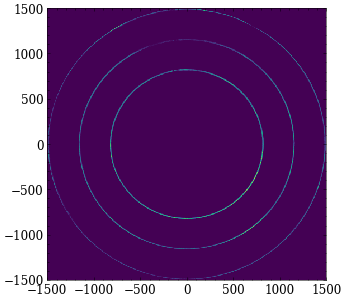

In [15]:
m = get_x_y_mask(X_samples["flow_samples"])
print("Num. hits before mask:", len(m))
print("Num. hits after mask:", sum(m))



plt.figure(figsize = (5,5))
plt.hist2d(X_samples["flow_samples"][:,1], X_samples["flow_samples"][:,2], bins = [np.linspace(-1500,1500,500), np.linspace(-1500,1500,500)])
plt.show()


plt.figure(figsize = (5,5))
plt.hist2d(X_samples["flow_samples"][m][:,1], X_samples["flow_samples"][m][:,2], bins = [np.linspace(-1500,1500,500), np.linspace(-1500,1500,500)])
plt.show()



UNAF M_2048


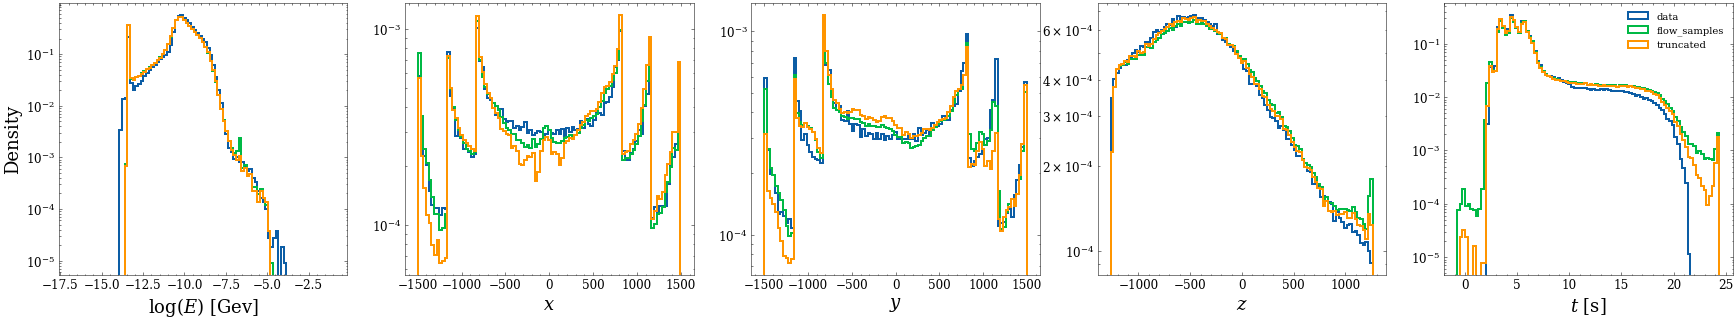

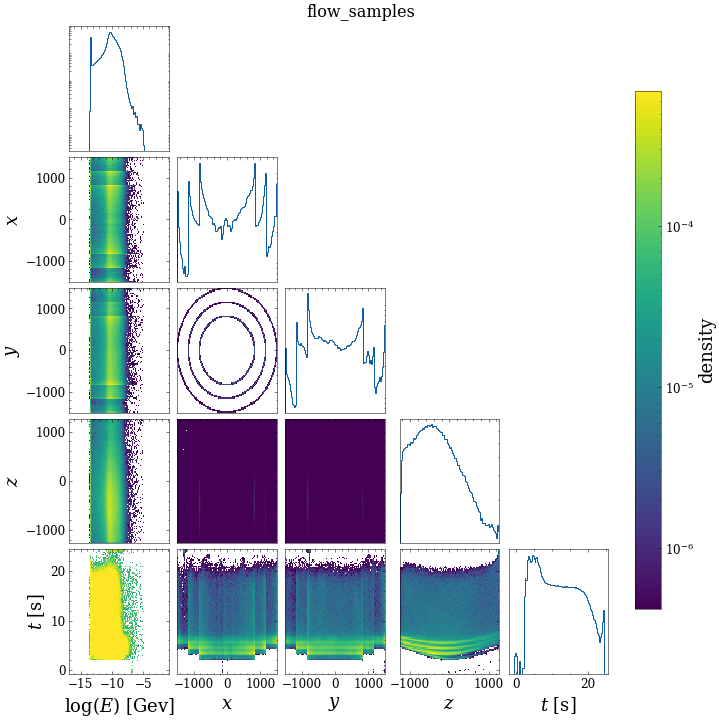

In [16]:
print(ZUKO_ID, NAME)
plot_hists_1d({"data":data, **X_samples, "truncated":X_samples["flow_samples"][m]}, bins_dict, log_dims=log_vars, labels=feature_labels)


fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key][m],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )

In [17]:
ks_dists_samples = get_kl_dist(data, X_samples["flow_samples"])
ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples["flow_samples"].shape))

                                        
for i, ks_dist in enumerate(ks_dists_samples):
    print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))

auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples["flow_samples"], n_runs=5, bdt_config="configs/bdt.yml")
print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")



Feature 0 KL div: 0.07229023941068141 (for gaussian: 0.0015248618784530488)
Feature 1 KL div: 0.017583793738489895 (for gaussian: 0.0014055248618785043)
Feature 2 KL div: 0.02130681399631673 (for gaussian: 0.0014084714548803223)
Feature 3 KL div: 0.026435359116022128 (for gaussian: 0.0010769797421730787)
Feature 4 KL div: 0.04483977900552483 (for gaussian: 0.0016898710865561606)
On BDT 1 of 5...
   auc=0.6422949986196324
On BDT 2 of 5...
   auc=0.6422727486408297
On BDT 3 of 5...
   auc=0.6430900451960155
On BDT 4 of 5...
   auc=0.6422770590234324
On BDT 5 of 5...
   auc=0.6429695947688477
auc 0.6425808892497515 \pm 0.0003685996885168664. best epoch 299 of 300.



In [ ]:
ks_dists_samples = get_kl_dist(data, X_samples["flow_samples"][m])
ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples["flow_samples"][m].shape))

                                        
for i, ks_dist in enumerate(ks_dists_samples):
    print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))

auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples["flow_samples"][m], n_runs=5, bdt_config="configs/bdt.yml")
print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")


Feature 0 KL div: 0.06897469851925808 (for gaussian: 0.002433292992739089)
Feature 1 KL div: 0.06318134382750329 (for gaussian: 0.001557390068533726)
Feature 2 KL div: 0.0396111859038033 (for gaussian: 0.0017024258640103707)
Feature 3 KL div: 0.013540905529551672 (for gaussian: 0.001651260226412432)
Feature 4 KL div: 0.03556186411737705 (for gaussian: 0.003106556690732676)
On BDT 1 of 5...
   auc=0.6437113170975297
On BDT 2 of 5...
   auc=0.6429697227037439
On BDT 3 of 5...
   auc=0.6435562840422951
On BDT 4 of 5...


In [ ]:

# save out
print(X_samples["flow_samples"])
print(X_samples["flow_samples"].shape)


In [ ]:

np.save(X_samples["flow_samples"], f"{working_dir}/npys/flow_samples/{COLLECTION_NAME}_{ZUKO_ID}_{NAME}")